# 1. Introduction

*Tensor decoupling* is a methodology for finding decoupled representations of multivariate functions. See [this paper](https://arxiv.org/abs/1410.4060) for more background information.

Formally, we look for a mapping
$$\mathbf{f}(\mathbf{x}) \to \mathbf{Wg}(\mathbf{V}^T \mathbf{x}),$$
where
- $\mathbf{f}: \mathbb{R}^m \to \mathbb{R}^n$,
- $\mathbf{W} \in \mathbb{R}^{n \times r}$,
- $\mathbf{V} \in \mathbb{R}^{m \times r}$,
- $\mathbf{g}: \mathbb{R}^{r} \to \mathbb{R}^r$ such that $\mathbf{g}(\mathbf{u}) = [g_1(u_1)\; g_2(u_2)\; \dots \; g_r(u_r)]^T$.

The integer $r > 0$ is called *rank*.

<center><img src="images/decoupling.png" width=700></center>

`Decoupling` is a library that implements algorithms and methods to find such representations.

Let's begin by importing the necessary libraries and defining our target function. For simplicity, we will use a simple polynomial, but we'll see later that decoupling algorithms can deal with more complex functions.

In [1]:
import jax, jax.numpy as jnp # we use jax because we need autodiff
jnp.set_printoptions(suppress=True, precision=2)

key = jax.random.key(42)
key_test = jax.random.key(43)

def target(x): # arbitrary polynomial
    x1, x2 = x
    return jnp.array([
        2*x1**3 + x2**2 + x1*x2 + 2,
        x2**3 + (x1+x2)**2 - x1 - 1,
    ])

# let's look at an example input/output
target(jnp.array([2, 3]))

Array([33, 49], dtype=int32)

To find the decoupled representation, we need to first collect information about our target, namely outputs and Jacobians (stacked into a 3d tensor).

We can use the `collect_information_from_random` function to do that for us.

By default, the sampling is $\mathcal{U}(0, 1)$ (but it can be changed by passing different `minval` and `maxval` values).

In [2]:
from decoupling.utils import collect_information_from_random

# number of data points to collect
ntrain = 100 
ntest = 50

# train set
X, Y, J = collect_information_from_random(target, ntrain, 2, key, minval=-1.1, maxval=1.1)
# returns inputs, outputs and stacked Jacobian tensor

# test set
X_test, _, _ = collect_information_from_random(target, ntest, 2, key_test, minval=-1.0, maxval=1.0)

X.shape, Y.shape, J.shape, X_test.shape

((100, 2), (100, 2), (2, 2, 100), (50, 2))

We can now run our tensor decoupling algorithm.

Every decoupling algorithm returns a `Decoupling` object, which is also callable.

We can also look at the `Algorithm.info` object, which contains information about the algorithm's best run.

In [3]:
from decoupling import Algorithm 

rank = 4

algorithm = Algorithm(
    rank, key,
    ninits=3,
    niters=100,
    use_smoothing=False,
)

decoupling = algorithm.run(X, Y, J)
print(f'CPD error: {algorithm.info.errors.min():.5f}')

[Seed 3/3]: 100%|████████████████████████████| 100/100 [00:00<00:00, 153.75it/s, error=0.0084, best=0.0082 (77), rcond=3.3e-02]


CPD error: 0.00818


It seems like our algorithm converged (error is very low).

Let's look at an example input / output (from the test set) to see if it makes sense.

In [4]:
y_decoupling = decoupling(X_test[1])
y_target = target(X_test[1])

print(f'Example target output:     {y_target}')
print(f'Example decoupling output: {y_decoupling}')

Example target output:     [ 2.36 -1.66]
Example decoupling output: [ 2.36 -1.65]


That looks quite good! The outputs are almost identical.

We can use the `function_error_from_callable` function to get the proper per-output error on the full test set. 

In [5]:
from decoupling.utils import function_error_from_callable

err1, err2 = function_error_from_callable(target, decoupling, X_test)
print(f'Error(y1) = {err1:.2f}, Error(y2) = {err2:.2f}')

Error(y1) = 0.38, Error(y2) = 0.95


Less than 1% error on each output, great!

Finally, we can take a look at our internal functions $g_1\;\dots\;g_r$.

This can give us some information about what the target function computes (imagine a black-box target scenario).

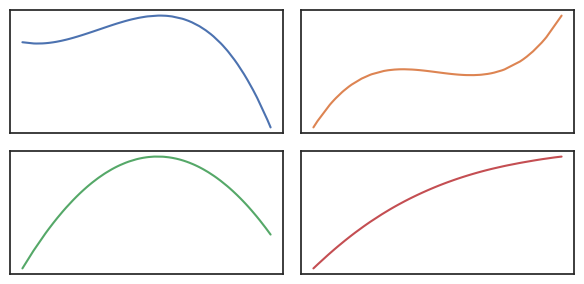

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook', 'white')
colors = sns.color_palette()

Z = jnp.stack(X @ decoupling.V)
Y = jnp.stack([decoupling.internals(z) for z in Z])

fig, ax = plt.subplots(2, 2, figsize=(6, 3))
for r, a in enumerate(ax.flatten()):
    a.set_xticks([]); a.set_yticks([])
    idx = jnp.argsort(Z[:, r])
    a.plot(Z[idx, r], Y[idx, r], color=colors[r])

plt.tight_layout()
plt.show()